In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
# Make plots look professional
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Load data (going up one folder to access the 'data' directory)
df = pd.read_csv('../data/energy_data_2024_2025.csv', parse_dates=['timestamp'], index_col='timestamp')

# 2. Basic info
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isna().sum())

# 3. Quick statistical summary
display(df.describe())

Dataset Shape: (17544, 5)

Missing Values:
 Wholesale_Prices            0
Electricity_Load            0
Generation_Solar            0
Generation_Wind_Onshore     0
Generation_Wind_Offshore    0
dtype: int64


,Wholesale_Prices,Electricity_Load,Generation_Solar,Generation_Wind_Onshore,Generation_Wind_Offshore
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,83.909579,53082.052619,7808.276208,12497.936956,2956.113145
std,52.691813,9132.995119,11801.383477,9621.480245,1980.677705
min,-250.320000,32413.250000,2.000000,46.500000,0.000000
25%,61.367500,45537.125000,8.000000,4919.375000,1175.250000
50%,86.355000,53172.500000,270.625000,10020.335000,2704.875000
75%,108.292500,59838.812500,12657.125000,17901.817500,4633.755000
max,936.280000,75635.210000,52132.250000,46332.250000,8278.070000


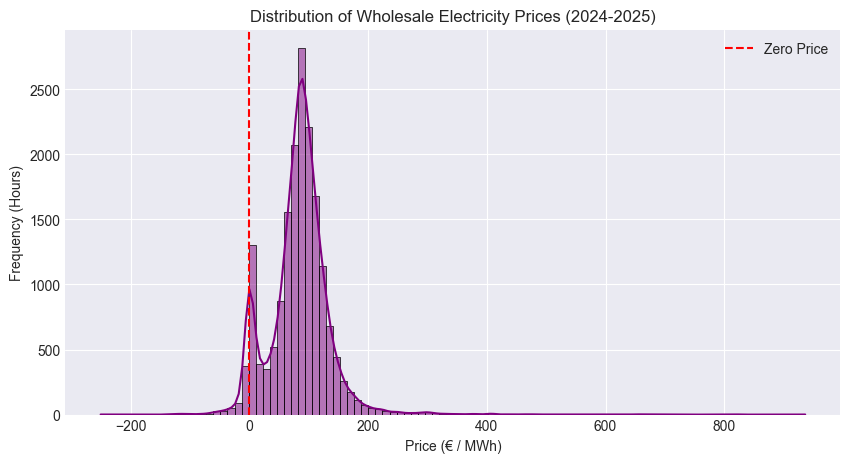

Total hours with negative prices: 1030


In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Wholesale_Prices'], bins=100, kde=True, color='purple')
plt.title('Distribution of Wholesale Electricity Prices (2024-2025)')
plt.xlabel('Price (€ / MWh)')
plt.ylabel('Frequency (Hours)')

# Draw a red line at 0 to highlight negative prices
plt.axvline(0, color='red', linestyle='--', label='Zero Price')
plt.legend()
plt.show()

negative_hours = (df['Wholesale_Prices'] < 0).sum()
print(f"Total hours with negative prices: {negative_hours}")

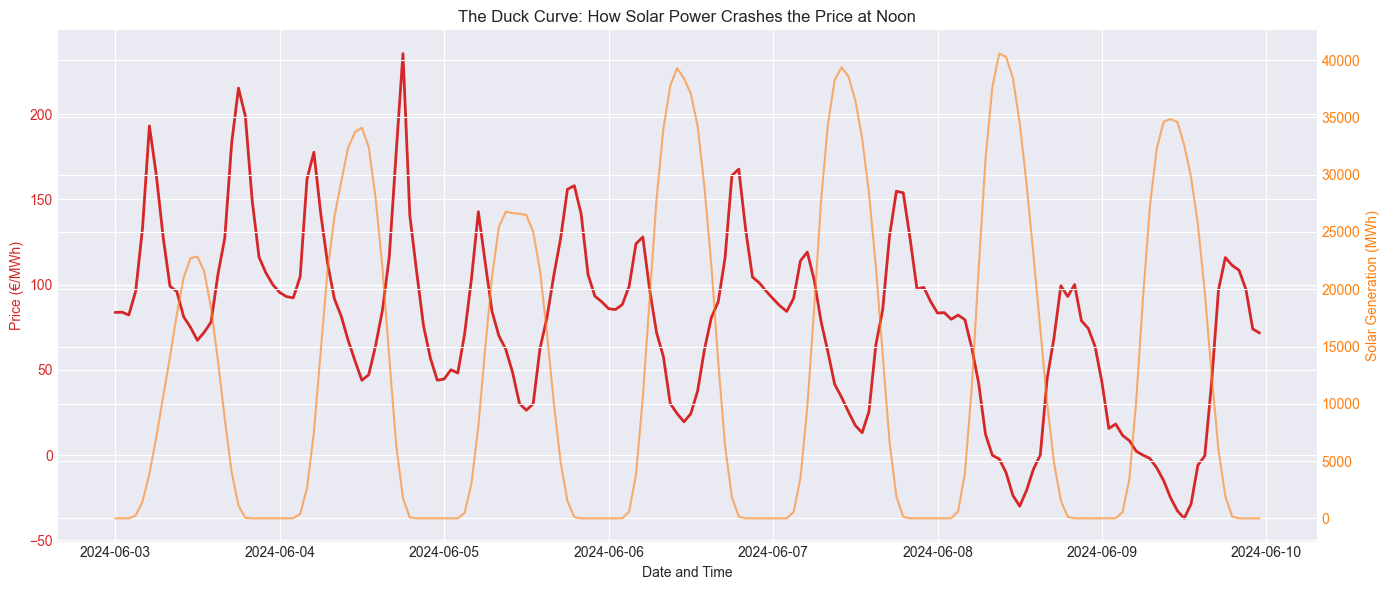

In [4]:
# Select one week of data in June 2024
summer_week = df.loc['2024-06-03':'2024-06-09']

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Price on the left Y-axis
color = 'tab:red'
ax1.set_xlabel('Date and Time')
ax1.set_ylabel('Price (€/MWh)', color=color)
ax1.plot(summer_week.index, summer_week['Wholesale_Prices'], color=color, linewidth=2, label='Price')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second Y-axis for Solar Generation
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Solar Generation (MWh)', color=color)  
ax2.plot(summer_week.index, summer_week['Generation_Solar'], color=color, alpha=0.6, label='Solar')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Duck Curve: How Solar Power Crashes the Price at Noon')
fig.tight_layout() 
plt.show()

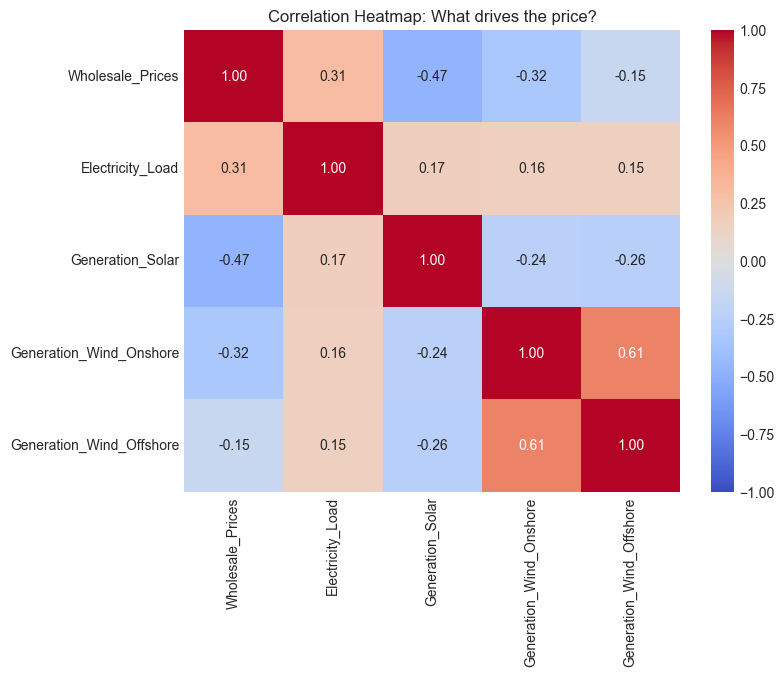

In [5]:
plt.figure(figsize=(8, 6))
# Calculate the Pearson correlation
corr_matrix = df.corr()

# Plot as a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: What drives the price?')
plt.show()

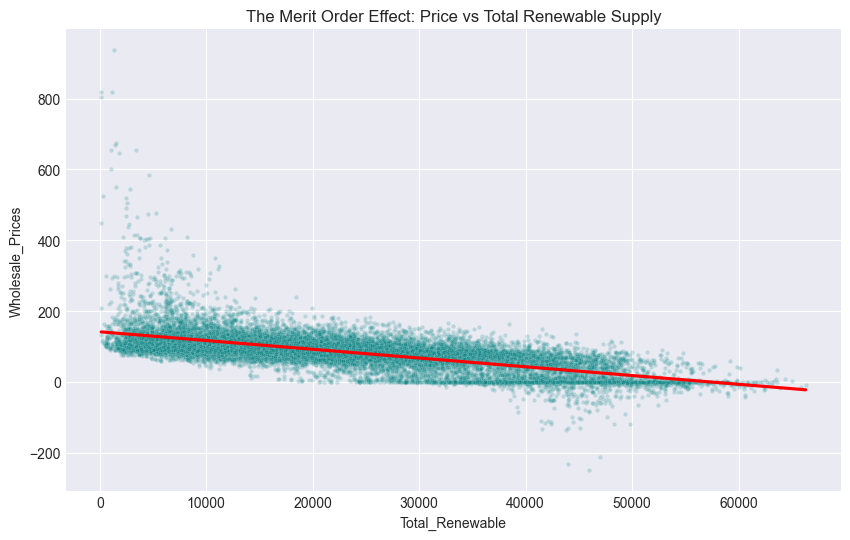

In [6]:
df['Total_Renewable'] = df['Generation_Solar'] + df['Generation_Wind_Onshore'] + df['Generation_Wind_Offshore']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Total_Renewable'], y=df['Wholesale_Prices'], alpha=0.2, s=10, color='teal')
plt.title('The Merit Order Effect: Price vs Total Renewable Supply')
plt.xlabel('Total Renewable Generation (MWh)')
plt.ylabel('Wholesale Price (€/MWh)')

# Add a trendline
sns.regplot(x=df['Total_Renewable'], y=df['Wholesale_Prices'], scatter=False, color='red')
plt.show()